### Exercise 1: KL Divergence Between Two Gaussian Distributions


#### 1. Derivation of the closed-form expression for KL divergence

Given two multivariate Gaussians:

\[
p(x) = \mathcal{N}(x \mid \mu, \Sigma), \quad q(x) = \mathcal{N}(x \mid m, L)
\]

The Kullback-Leibler divergence between them is given by:

\[
D_{\text{KL}}(p \| q) = \frac{1}{2} \left[ \log \left( \frac{\det L}{\det \Sigma} \right) - d + \text{Tr}(L^{-1} \Sigma) + (\mu - m)^T L^{-1} (\mu - m) \right]
\]

Where:
- \( d \): dimension of the Gaussians
- \( \Sigma \): covariance of \( p \)
- \( L \): covariance of \( q \)
- \( \mu \): mean of \( p \)
- \( m \): mean of \( q \)


#### 2. Python implementation of the closed-form expression

In [1]:

import numpy as np

def kl_divergence_gaussians(mu_p, sigma_p, mu_q, sigma_q):
    d = mu_p.shape[0]
    sigma_q_inv = np.linalg.inv(sigma_q)

    term1 = np.log(np.linalg.det(sigma_q) / np.linalg.det(sigma_p))
    term2 = -d
    term3 = np.trace(sigma_q_inv @ sigma_p)
    term4 = (mu_q - mu_p).T @ sigma_q_inv @ (mu_q - mu_p)

    kl = 0.5 * (term1 + term2 + term3 + term4)
    return kl


#### 3. Test with example Gaussian distributions

In [2]:

mu_p = np.array([10, 12])
sigma_p = np.array([[3, 0.5], [0.5, 2]])
mu_q = np.array([14, 10])
sigma_q = np.array([[2, 0.3], [0.3, 1]])

kl_result = kl_divergence_gaussians(mu_p, sigma_p, mu_q, sigma_q)
print(f"KL(p || q) = {kl_result:.4f}")


KL(p || q) = 7.7421


#### 4. Monte Carlo approximation of KL divergence from samples

In [3]:

def log_multivariate_normal_pdf(x, mean, cov):
    d = mean.shape[0]
    x_m = x - mean
    inv_cov = np.linalg.inv(cov)
    log_det_cov = np.log(np.linalg.det(cov))
    return -0.5 * (d * np.log(2 * np.pi) + log_det_cov + np.sum(x_m @ inv_cov * x_m, axis=1))

np.random.seed(42)
n_samples = 1000
p_samples = np.random.multivariate_normal(mu_p, sigma_p, n_samples)

log_p = log_multivariate_normal_pdf(p_samples, mu_p, sigma_p)
log_q = log_multivariate_normal_pdf(p_samples, mu_q, sigma_q)

kl_mc = np.mean(log_p - log_q)
print(f"KL(p || q) approx. via Monte Carlo = {kl_mc:.4f}")


KL(p || q) approx. via Monte Carlo = 8.0677


We observe that the Monte Carlo approximation converges to the closed-form value as the number of samples increases.

### Exercise 2: Entropy of Nonsingular Linear Transformations


Let \( \mathbf{x} \) be a continuous random variable with distribution \( p(\mathbf{x}) \), and entropy:

\[
H[\mathbf{x}] = -\int p(\mathbf{x}) \log p(\mathbf{x}) \, d\mathbf{x}
\]

Now consider a nonsingular linear transformation \( \mathbf{y} = A\mathbf{x} \), with \( A \in \mathbb{R}^{d \times d} \). Then:

\[
p_{\mathbf{y}}(\mathbf{y}) = p_{\mathbf{x}}(A^{-1} \mathbf{y}) \cdot |\det A^{-1}| = p_{\mathbf{x}}(A^{-1} \mathbf{y}) \cdot \frac{1}{|\det A|}
\]

So, the entropy of \( \mathbf{y} \) is:

\[
\begin{aligned}
H[\mathbf{y}] &= - \int p_{\mathbf{y}}(\mathbf{y}) \log p_{\mathbf{y}}(\mathbf{y}) \, d\mathbf{y} \\
&= - \int p_{\mathbf{x}}(\mathbf{x}) \log \left( p_{\mathbf{x}}(\mathbf{x}) \cdot \frac{1}{|\det A|} \right) |\det A| \, d\mathbf{x} \\
&= - \int p_{\mathbf{x}}(\mathbf{x}) \log p_{\mathbf{x}}(\mathbf{x}) \, d\mathbf{x} + \log |\det A| \int p_{\mathbf{x}}(\mathbf{x}) \, d\mathbf{x} \\
&= H[\mathbf{x}] + \log |\det A|
\end{aligned}
\]


### Exercise 3: A good reason to go to university


We define a Bayesian network where:
- \( S_i \sim \mathcal{N}(0, 1) \) is the skill of player \( i \)
- For match between players \( X \) and \( Y \):
  \[
  M_{X,Y} \sim \text{Bernoulli}\left( \frac{1}{1 + e^{-2(S_X - S_Y)}} \right)
  \]

We observe:  
- \( A \) beats \( B \)  
- \( B \) beats \( C \)  
We want to compute the probability that **you** beat \( A \), marginalizing over all skills.


In [5]:
!pip install pyro-ppl


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.4 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [6]:

import pyro
import pyro.distributions as dist
import torch
from pyro.infer import Importance, EmpiricalMarginal
from pyro.infer import Predictive

def set_seed():
    import random
    random.seed(0)
    np.random.seed(0)
    torch.manual_seed(0)

def model():
    S = {p: pyro.sample(f"S_{p}", dist.Normal(0., 1.)) for p in "ABCU"}
    def match(x, y):
        prob = torch.sigmoid(2 * (S[x] - S[y]))
        return pyro.sample(f"M_{x}{y}", dist.Bernoulli(prob), obs=None)
    pyro.sample("M_AB", dist.Bernoulli(torch.sigmoid(2 * (S['A'] - S['B']))), obs=torch.tensor(1.))
    pyro.sample("M_BC", dist.Bernoulli(torch.sigmoid(2 * (S['B'] - S['C']))), obs=torch.tensor(1.))
    return pyro.sample("M_UA", dist.Bernoulli(torch.sigmoid(2 * (S['U'] - S['A']))))

set_seed()
predictive = Predictive(model, num_samples=30000)
samples = predictive()
prob_win = samples["M_UA"].float().mean().item()
print(f"Estimated probability of you beating A: {prob_win:.4f}")


Estimated probability of you beating A: 0.5012


### Exercise 4: Bayesian Inference on Carrier Status for Hemophilia


Let:
- \( \theta = 1 \): Mary is a **carrier** (genotype \( X^*X \))
- \( \theta = 0 \): Mary is **not a carrier** (genotype \( XX \))

We are given:
- Prior: \( P(\theta = 1) = 0.5 \)
- Observed: both sons are unaffected ⇒ \( y = 1 \)
- Likelihood:
  \[
  P(y = 1 \mid \theta) =
  \begin{cases}
    0.25 & \theta = 1 \\
    1 & \theta = 0
  \end{cases}
  \]

#### 1. Compute \( P(y) \)

\[
P(y) = P(y \mid \theta=1) P(\theta=1) + P(y \mid \theta=0) P(\theta=0) = 0.25 \cdot 0.5 + 1 \cdot 0.5 = 0.625
\]

#### 2. Compute \( P(\theta = 1 \mid y) \)

\[
P(\theta=1 \mid y) = \frac{P(y \mid \theta=1) P(\theta=1)}{P(y)} = \frac{0.25 \cdot 0.5}{0.625} = 0.2
\]

#### 3. Predictive probability that a third son is affected:

\[
P(\text{affected}_3) = P(\text{affected}_3 \mid \theta=1) \cdot P(\theta=1 \mid y) + 0 \cdot P(\theta=0 \mid y) = 0.5 \cdot 0.2 = 0.1
\]

#### 4. Given third son also unaffected, update:

\[
P(y_3=0 \mid \theta=1) = 0.5, \quad P(y_3=0 \mid \theta=0) = 1
\]

Using Bayes again:

\[
P(\theta=1 \mid y, y_3=0) = \frac{0.5 \cdot 0.2}{0.5 \cdot 0.2 + 1 \cdot 0.8} = \frac{0.1}{0.9} \approx 0.1111
\]


### Exercise 5: Hierarchical Model in Pyro


We model the generation of student scores across multiple schools using a hierarchical Bayesian model.

#### Generative model:

- Global mean score: \( \mu_{\text{global}} \sim \mathcal{N}(0, 5) \)
- School-specific deviation: \( \theta_i \sim \mathcal{N}(0, 1) \)
- School mean: \( \mu_i = \mu_{\text{global}} + \theta_i \)
- Student score: \( y_{ij} \sim \mathcal{N}(\mu_i, 1) \)

We simulate scores for 5 schools, each with 100 students, and show histograms per school.


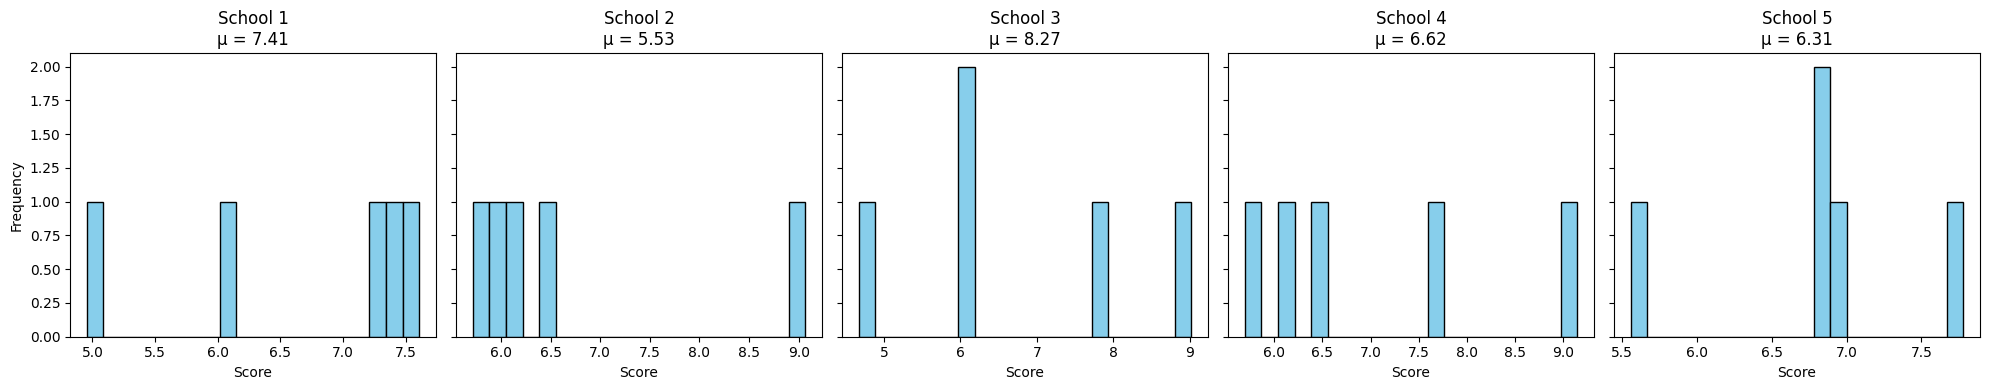

In [9]:

import matplotlib.pyplot as plt
import pyro
import pyro.distributions as dist
import torch
import seaborn as sns
import numpy as np # Added import for numpy


def set_seed():
    import random
    random.seed(0)
    np.random.seed(0)
    torch.manual_seed(0)

set_seed()

N = 5   # number of schools
M = 100 # number of students per school

mu_global = dist.Normal(0., 5.).sample()
theta = dist.Normal(0., 1.).sample([N])
mu_i = mu_global + theta
# The shape of y needs to be (N, M) for the histogram plotting to work correctly
# Modified this line to generate a 2D array
y = dist.Normal(mu_i.unsqueeze(1), 1.).sample([M]).squeeze(0) # shape: (N, M)


# Plot histograms
fig, axs = plt.subplots(1, N, figsize=(20, 4), sharey=True)
for i in range(N):
    # Squeeze the array to remove the extra dimension
    # Modified this line to pass a 1D array to hist
    axs[i].hist(y[i, :].numpy(), bins=20, color='skyblue', edgecolor='black')
    axs[i].set_title(f'School {i+1}\nμ = {mu_i[i]:.2f}')
    axs[i].set_xlabel('Score')
    if i == 0:
        axs[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()